In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scipy
import solver
import sde
import gaussians

torch.manual_seed(0)

In [41]:
# SDE Setup
beta_min = 0.1
beta_max = 20
sde = sde.LinearVariancePreservingSDE(beta_min, beta_max)

In [42]:
# Gaussian & score setup
gaussian1 = gaussians.Gaussian(
    mu=0,
    sigma=1,
    weight=1/8
)
gaussian2 = gaussians.Gaussian(
    mu=-50,
    sigma=3,
    weight=2/8
)

gaussian3 = gaussians.Gaussian(
    mu=15,
    sigma=5,
    weight=1/2
)

gaussian4 = gaussians.Gaussian(
    mu=-20,
    sigma=10,
    weight= 1/8
)

multi_gaussian = gaussians.MultiGaussian((gaussian1, gaussian2, gaussian3, gaussian4), sde)
score_func = multi_gaussian.get_score_function()

# Create reverse sde based on score function
reverse_sde = sde.get_reverse_sde(score_func)

Text(0.5, 1.0, 'Samples from distribution')

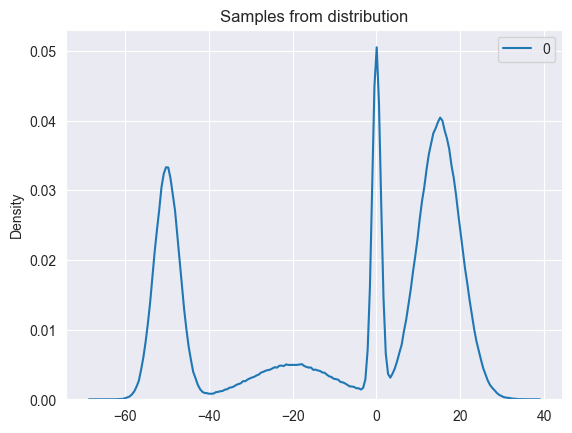

In [43]:
# Sampling
n_samples = 1000000
samples = multi_gaussian.sample(n_samples).unsqueeze(-1)
x_ground_truth = torch.sort(samples)[0]

plt.figure()
sns.kdeplot(x_ground_truth, bw_adjust=0.1)
plt.title("Samples from distribution")

Text(0.5, 1.0, 'Data before transformation')

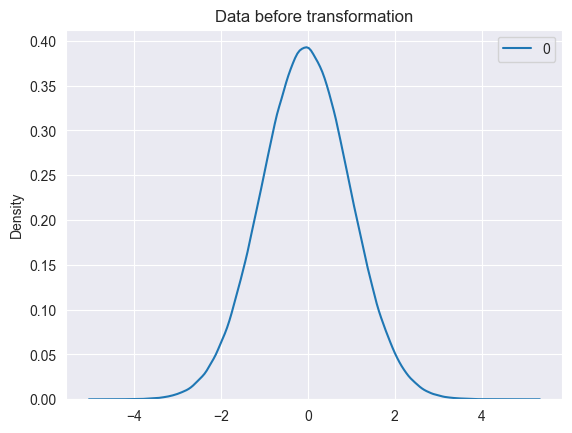

In [44]:
# Sample x from the marginal
x_start = sde.sample(x_ground_truth, torch.Tensor([1]))

# Plot initial data
plt.figure()
sns.kdeplot(x_start)
plt.title("Data before transformation")

In [117]:
# Euler Marayuma setup
multi_gaussian.reset_nfe()

n_steps = 67
discretisation = torch.linspace(1, 0, n_steps)
em_solver = solver.EulerMarayumaSolver(reverse_sde, discretisation)

x_em = em_solver.solve(x_start.clone())

# Baseline PDF
interval = torch.linspace(torch.min(x_em) - 3, torch.max(x_em) + 3, 10000).unsqueeze(-1)
verification = multi_gaussian(interval)

Text(0.5, 1.0, 'EM solver transforming to a multimodal Gaussian')

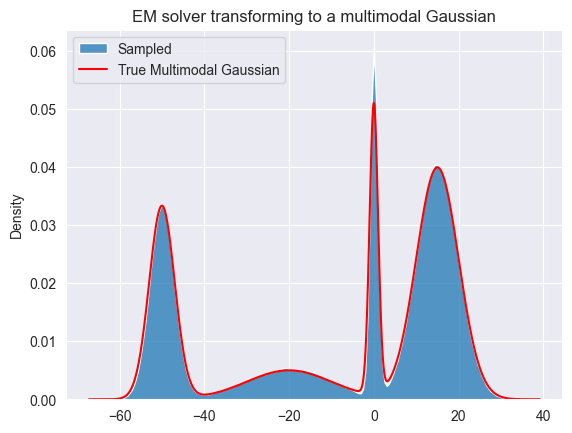

In [46]:
# Euler Marayuma Plots
plt.figure()
sns.kdeplot(x_em, label="Sampled", multiple="stack", bw_adjust=0.1)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("EM solver transforming to a multimodal Gaussian")

In [118]:
# Euler Marayuma Evaluation
nfe_em_per_sample = multi_gaussian.nfe / n_samples
wasserstein_distance_em = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_em)[0][:, 0])

print(f"NFE per sample for Euler-Marayuma sampler: {nfe_em_per_sample}")
print(f"Wasserstein distance for Euler-Marayuma sampler: {wasserstein_distance_em}")

NFE per sample for Euler-Marayuma sampler: 66.0
Wasserstein distance for Euler-Marayuma sampler: 1.0845692966483411


In [115]:
# PI solver setup
multi_gaussian.reset_nfe()

pi_solver = solver.PISolver(
    reverse_sde,
    ki=0.101, 
    kp=0.09, 
    tau=0.5, 
    alpha=0.5, 
    h_start=0.01, 
    max_decrease=0.7, 
    max_increase=1.15
)

x_pi = pi_solver.solve(x_start.clone())

# Baseline PDF
interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 10000).reshape((10000, 1))
verification = multi_gaussian(interval)

tensor(7.8787e-06)
50


Text(0.5, 1.0, 'PI adaptive solver transforming to a multimodal Gaussian')

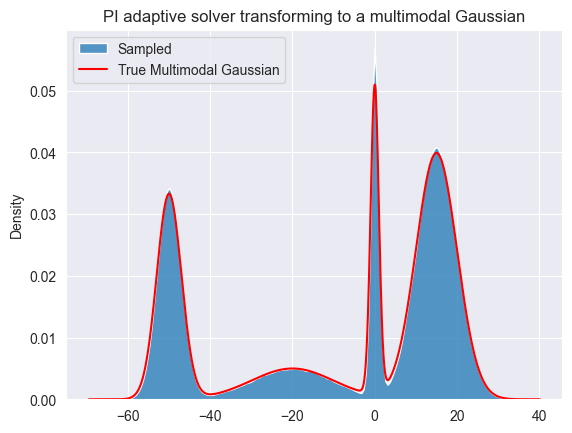

In [49]:
# PI Plots
plt.figure()
sns.kdeplot(x_pi, label="Sampled", multiple="stack", bw_adjust=0.2)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("PI adaptive solver transforming to a multimodal Gaussian")

In [116]:
# PI Evaluation
nfe_pi_per_sample = multi_gaussian.nfe / n_samples
wasserstein_distance_pi = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_pi)[0][:, 0])

print(f"NFE per sample for PI sampler: {nfe_pi_per_sample}")
print(f"Wasserstein distance for PI sampler: {wasserstein_distance_pi}")

NFE per sample for PI sampler: 65.493102
Wasserstein distance for PI sampler: 0.26425541524108004
